In [1]:
import sys
import subprocess
sys.path.insert(0, '..')

try:
    import numdifftools  # noqa: F401
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'numdifftools'])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from scipy.stats import norm
warnings.filterwarnings('ignore')

T_WINDOW = 30

# Exact imports from solarrpy
from solarrpy.buyer import (
    compute_buyer_table, unhedged_cf, benchmark_cf, hedged_cf,
    optimal_Nc, mape, E_f, N_p, E_bar, tick,
)
from solarrpy.sorad import daily_strike, sorad_price, G_integral
from solarrpy.forecastDensity import clearsky_at, seasonal_mean_Y_at
from solarrpy.calibration import calibrate_window

# ASoRad (Asian SoRad) helpers

def asian_strike(*, dates=None, cal=None, T=None, ghi_window=None) -> float:
    """ATM strike for Asian SoRad."""
    if ghi_window is not None:
        return float(np.mean(ghi_window))
    if dates is None or cal is None:
        raise TypeError("asian_strike needs either ghi_window or dates+cal")
    dates = pd.to_datetime(dates)
    strikes = [daily_strike(d, cal) for d in dates]
    return float(np.mean(strikes))


def _asian_average_period_moments(dates, cal):
    """Average clear-sky level, mean Y, and CLT standard deviation over a window."""
    dates = pd.to_datetime(dates)
    if len(dates) == 0:
        return 0.0, 0.0, 0.0

    clear_sky = np.array([clearsky_at(d, cal) for d in dates], dtype=float)
    mean_y = np.array([seasonal_mean_Y_at(d, cal) for d in dates], dtype=float)

    var_y = []
    for d in dates:
        month = pd.Timestamp(d).month
        row = cal.monthly_mixture.loc[cal.monthly_mixture['Month'] == month].iloc[0]
        var_y.append(float(row['variance']))

    theta = float(cal.theta)
    cov_sum = 0.0
    for i, var_i in enumerate(var_y):
        for j, var_j in enumerate(var_y):
            rho_ij = np.exp(-theta * abs(i - j))
            cov_sum += rho_ij * np.sqrt(var_i * var_j)

    sigma_bar_y = float(np.sqrt(max(cov_sum, 0.0)) / len(dates))
    return float(clear_sky.mean()), float(mean_y.mean()), max(sigma_bar_y, 1e-12)


def asian_sorad_price(
    K: float | None = None,
    R_t0: float | None = None,
    cal=None,
    dates=None,
    T: int | None = None,
    n: int | None = None,
    K_bar: float | None = None,
) -> float:
    """
    Semi-analytical Asian SoRad put price.

    This follows the proposed-products definition more closely by pricing the
    put on the average radiation using average-period moments in Y-space and
    the same SoRad back-transform used by the base product.
    """
    if K is None:
        K = K_bar
    if K is None:
        raise TypeError("asian_sorad_price needs K or K_bar")
    if dates is None:
        raise TypeError("asian_sorad_price needs dates")

    dates = pd.to_datetime(dates)
    if len(dates) == 0:
        return 0.0

    C_bar, mu_bar_y, sigma_bar_y = _asian_average_period_moments(dates, cal)
    alpha, beta = cal.alpha, cal.beta

    inner = 1.0 - alpha - float(K) / C_bar
    if inner <= 0.0 or inner >= beta:
        raise ValueError(
            f"K={K} is outside the valid average-radiation range for C_bar={C_bar:.4f}."
        )

    K_Y = float(np.log(np.log(beta) - np.log(inner)))
    z = (K_Y - mu_bar_y) / sigma_bar_y

    price = (
        (float(K) - C_bar * (1.0 - alpha)) * norm.cdf(z)
        + C_bar * beta * G_integral(K_Y, mu_bar_y, sigma_bar_y)
    )
    return float(max(price * tick, 0.0))


# BSoRad (Barrier SoRad) helpers

def barrier_sorad_price(
    K: float,
    R_t0: float,
    cal,
    barrier: float,
    n_sim: int = 50_000,
    seed: int = 42,
) -> float:
    """
    Price one Down-and-In Barrier SoRad put via Monte Carlo.

    Payoff = max(K - R_T, 0) · tick  if  min(R_t) <= barrier,  else 0.

    Parameters
    ----------
    K        : float – put strike (ATM daily strike)
    R_t0     : float – last observed GHI
    cal             – calibrated model from calibrate_window
    barrier  : float – knock-in barrier level (e.g. 0.5 * K)
    n_sim    : int   – number of MC paths
    seed     : int   – RNG seed for reproducibility
    """
    rng = np.random.default_rng(seed)

    mu    = cal.mu
    sigma = cal.sigma
    T     = 1            # single day horizon (daily contract)

    # Simulate R_T under Q (log-normal approximation used by sorad_price)
    Z      = rng.standard_normal(n_sim)
    R_T    = mu + sigma * Z                          # normal model (matching sorad)
    R_path_min = np.minimum(R_t0, R_T)              # 2-point min (t0 and T)

    knocked_in = R_path_min <= barrier               # barrier condition
    intrinsic  = np.maximum(K - R_T, 0.0)
    payoff     = np.where(knocked_in, intrinsic, 0.0)

    return float(np.mean(payoff))                    # risk-neutral price (pre-tick)

In [2]:
df = pd.read_csv('../data/Bologna.csv', parse_dates=['date'])
print(f'Full dataset: {len(df)} rows, years {df["Year"].min()}–{df["Year"].max()}')
print(f'Buyer params: E_f={E_f}, N_p={N_p}, E_bar={E_bar}, tick={tick}')
print(f'Asian window T={T_WINDOW} days')

Full dataset: 7465 rows, years 2005–2025
Buyer params: E_f=0.15, N_p=10000, E_bar=0.08, tick=0.1
Asian window T=30 days


In [3]:
def build_windows(df_year, T):
    """Split a yearly DataFrame into non-overlapping windows of T days."""
    df_year = df_year.reset_index(drop=True)
    windows = []
    n = len(df_year)
    for start in range(0, n - T + 1, T):
        chunk = df_year.iloc[start:start + T]
        windows.append(chunk)
    return windows


def asian_unhedged_cf(R_bar, T):
    """Unhedged cash flow for the buyer over one window of T days."""
    return E_f * N_p * R_bar * E_bar * T


def asian_benchmark_cf(K_A, T):
    """Benchmark (target) cash flow: revenue at strike level."""
    return E_f * N_p * K_A * E_bar * T


def asian_hedged_cf(R_bar, K_A, V0_A, Nc, T):
    """Hedged cash flow for the buyer over one window."""
    payoff = max(K_A - R_bar, 0.0)
    return (
        asian_unhedged_cf(R_bar, T)
        + Nc * (payoff * tick - V0_A * tick)
    )


def asian_optimal_Nc(windows_data):
    """
    Closed-form optimal N_c minimising sum of squared deviations
    from the benchmark cash flow over all windows.

    windows_data: list of dicts with keys R_bar, K_A, V0_A, T
    """
    numerator = 0.0
    denominator = 0.0
    for w in windows_data:
        R_bar  = w['R_bar']
        K_A    = w['K_A']
        V0_A   = w['V0_A']
        T      = w['T']
        CF_u   = asian_unhedged_cf(R_bar, T)
        CF_b   = asian_benchmark_cf(K_A, T)
        payoff = max(K_A - R_bar, 0.0)
        delta  = (payoff - V0_A) * tick
        numerator   += (CF_b - CF_u) * delta
        denominator += delta ** 2
    return numerator / denominator if denominator != 0 else 0.0


print('Helper functions defined.')

Helper functions defined.


In [28]:
print('Running Asian SoRad buyer train-test loop 2014–2023...')

eval_years = list(range(2014, 2024))
records = []

for eval_year in eval_years:
    # --- Training set: all years strictly before eval_year ---
    df_train = df[df['Year'] < eval_year].copy()
    first_train = df_train['Year'].min()
    print(f'  [{eval_year}] Training {first_train}–{eval_year - 1}... ', end='', flush=True)

    # Calibrate model on training data
    cal = calibrate_window(
        df_train,
        train_end_year=eval_year - 1,
        coords={'lat': 44.5},
    )

    # --- Evaluation set: the eval_year ---
    df_eval = df[df['Year'] == eval_year].copy()
    windows = build_windows(df_eval, T_WINDOW)

    windows_data = []
    for win in windows:
        dates_w = win['date'].values
        R_vals  = win['GHI'].values       # daily radiation index
        R_bar_w = R_vals.mean()           # average over window

        # ATM strike = model conditional mean of R_bar for this window
        K_A_w = asian_strike(
            dates=dates_w,
            cal=cal,
            T=T_WINDOW,
        )

        # Asian put price (CLT / G-integral approximation)
        V0_A_w = asian_sorad_price(
            K=K_A_w,
            dates=dates_w,
            cal=cal,
            T=T_WINDOW,
        )

        windows_data.append({
            'R_bar': R_bar_w,
            'K_A':   K_A_w,
            'V0_A':  V0_A_w,
            'T':     T_WINDOW,
        })

    # Optimal N_c
    Nc = asian_optimal_Nc(windows_data)

    # MAPE unhedged and hedged
    CF_u_list = [asian_unhedged_cf(w['R_bar'], w['T']) for w in windows_data]
    CF_b_list = [asian_benchmark_cf(w['K_A'],  w['T']) for w in windows_data]
    CF_h_list = [
        asian_hedged_cf(w['R_bar'], w['K_A'], w['V0_A'], Nc, w['T'])
        for w in windows_data
    ]

    MAPE_u = 100.0 * np.mean(
        [abs(CF_u - CF_b) / abs(CF_b) for CF_u, CF_b in zip(CF_u_list, CF_b_list)]
    )
    MAPE_h = 100.0 * np.mean(
        [abs(CF_h - CF_b) / abs(CF_b) for CF_h, CF_b in zip(CF_h_list, CF_b_list)]
    )

    # Seller net P&L (sum over all windows in the year)
    seller_net = sum(
        Nc * (w['V0_A'] - max(w['K_A'] - w['R_bar'], 0.0)) * tick
        for w in windows_data
    )

    print(f'N_c={Nc:.1f}  MAPE_u={MAPE_u:.2f}%  MAPE_h={MAPE_h:.2f}%  seller={seller_net:.2f}€')

    records.append({
        'eval_year':      eval_year,
        'n_windows':      len(windows_data),
        'N_c_opt':        Nc,
        'unhedged_MAPE':  MAPE_u,
        'hedged_MAPE':    MAPE_h,
        'seller_net_eur': seller_net,
        # Store for plotting
        '_windows_data':  windows_data,
        '_CF_u':          CF_u_list,
        '_CF_b':          CF_b_list,
        '_CF_h':          CF_h_list,
    })

table2A = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')} for r in records])
print('\nDone.')

Running Asian SoRad buyer train-test loop 2014–2023...
  [2014] Training 2005–2013... N_c=36955.3  MAPE_u=10.52%  MAPE_h=0.88%  seller=-18970.14€
  [2015] Training 2005–2014... N_c=37144.8  MAPE_u=7.82%  MAPE_h=3.35%  seller=-9133.77€
  [2016] Training 2005–2015... N_c=37217.0  MAPE_u=10.14%  MAPE_h=2.18%  seller=-15086.19€
  [2017] Training 2005–2016... N_c=40960.7  MAPE_u=9.12%  MAPE_h=6.63%  seller=-4497.37€
  [2018] Training 2005–2017... N_c=36909.2  MAPE_u=10.68%  MAPE_h=1.83%  seller=-14653.74€
  [2019] Training 2005–2018... N_c=36766.0  MAPE_u=14.47%  MAPE_h=7.06%  seller=-15720.42€
  [2020] Training 2005–2019... N_c=38622.3  MAPE_u=11.05%  MAPE_h=6.57%  seller=-7153.62€
  [2021] Training 2005–2020... N_c=37367.0  MAPE_u=8.79%  MAPE_h=2.80%  seller=-12100.41€
  [2022] Training 2005–2021... N_c=37783.8  MAPE_u=10.69%  MAPE_h=5.62%  seller=-7907.39€
  [2023] Training 2005–2022... N_c=36700.2  MAPE_u=9.10%  MAPE_h=3.90%  seller=-11943.12€

Done.


In [23]:
print('Table 2A: Buyer/Seller Analysis — Asian SoRad (Bologna, 2014–2023)')
print('=' * 80)
display_cols = ['eval_year', 'n_windows', 'N_c_opt', 'unhedged_MAPE', 'hedged_MAPE', 'seller_net_eur']
print(table2A[display_cols].to_string(index=False, float_format='{:.3f}'.format))

print(f'\nHedged MAPE < Unhedged MAPE: {(table2A["hedged_MAPE"] < table2A["unhedged_MAPE"]).sum()}/10 years')
print(f'Mean unhedged MAPE: {table2A["unhedged_MAPE"].mean():.2f}%')
print(f'Mean hedged MAPE:   {table2A["hedged_MAPE"].mean():.2f}%')
print(f'Mean seller net:    {table2A["seller_net_eur"].mean():.2f} €/year')

table2A.to_csv('../results/Table2A_Asian_Buyer.csv', index=False, float_format='%.6f')
print('\nSaved to results/Table2A_Asian_Buyer.csv')

Table 2A: Buyer/Seller Analysis — Asian SoRad (Bologna, 2014–2023)
 eval_year  n_windows  N_c_opt  unhedged_MAPE  hedged_MAPE  seller_net_eur
      2014         12 1231.848         10.516        0.879      -18970.160
      2015         12 1238.173          7.815        3.350       -9133.702
      2016         12 1240.554         10.141        2.183      -15086.282
      2017         12 1365.259          9.119        6.627       -4497.385
      2018         12 1230.305         10.683        1.828      -14653.754
      2019         12 1225.532         14.473        7.055      -15720.425
      2020         12 1287.408         11.052        6.573       -7153.638
      2021         12 1245.566          8.791        2.797      -12100.400
      2022         12 1259.461         10.691        5.616       -7907.424
      2023         12 1223.329          9.102        3.900      -11942.873

Hedged MAPE < Unhedged MAPE: 10/10 years
Mean unhedged MAPE: 10.24%
Mean hedged MAPE:   4.08%
Mean seller n

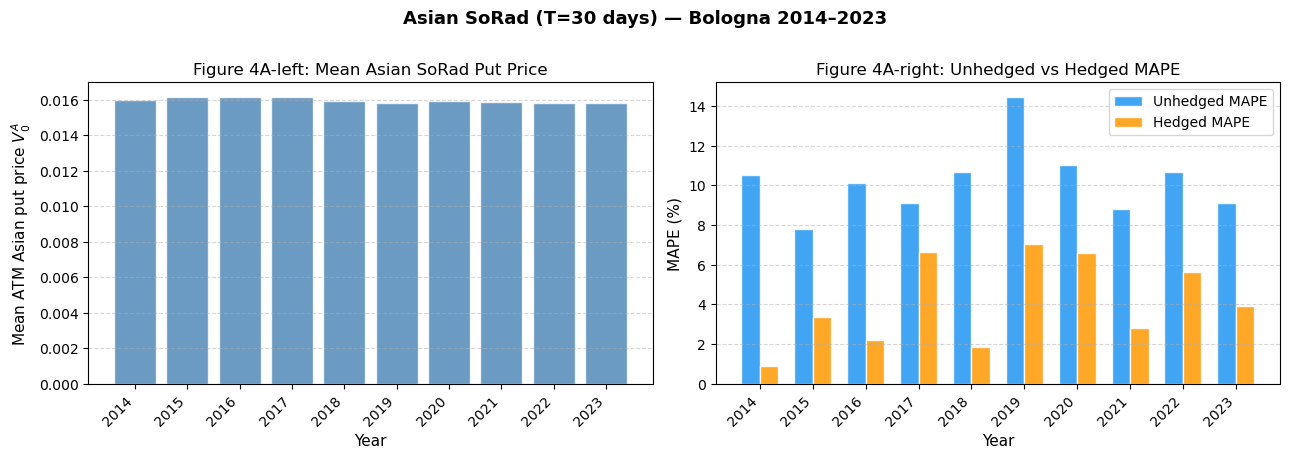

Saved to results/Figure4A_Asian_Prices_MAPE.png


In [24]:
# Collect mean V0_A per year
mean_V0A = [np.mean([w['V0_A'] for w in r['_windows_data']]) for r in records]
years    = table2A['eval_year'].values

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: mean Asian put price per year
ax = axes[0]
ax.bar(years, mean_V0A, color='steelblue', alpha=0.8, edgecolor='white')
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Mean ATM Asian put price $V_0^A$', fontsize=11)
ax.set_title('Figure 4A-left: Mean Asian SoRad Put Price', fontsize=12)
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Right: MAPE comparison
ax2 = axes[1]
x     = np.arange(len(years))
width = 0.35
ax2.bar(x - width/2, table2A['unhedged_MAPE'].values, width,
        label='Unhedged MAPE', color='#2196F3', alpha=0.85, edgecolor='white')
ax2.bar(x + width/2, table2A['hedged_MAPE'].values,   width,
        label='Hedged MAPE',   color='#FF9800', alpha=0.85, edgecolor='white')
ax2.set_xlabel('Year', fontsize=11)
ax2.set_ylabel('MAPE (%)', fontsize=11)
ax2.set_title('Figure 4A-right: Unhedged vs Hedged MAPE', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(years, rotation=45, ha='right')
ax2.legend(fontsize=10)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

fig.suptitle(
    f'Asian SoRad (T={T_WINDOW} days) — Bologna 2014–2023',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('../results/Figure4A_Asian_Prices_MAPE.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to results/Figure4A_Asian_Prices_MAPE.png')

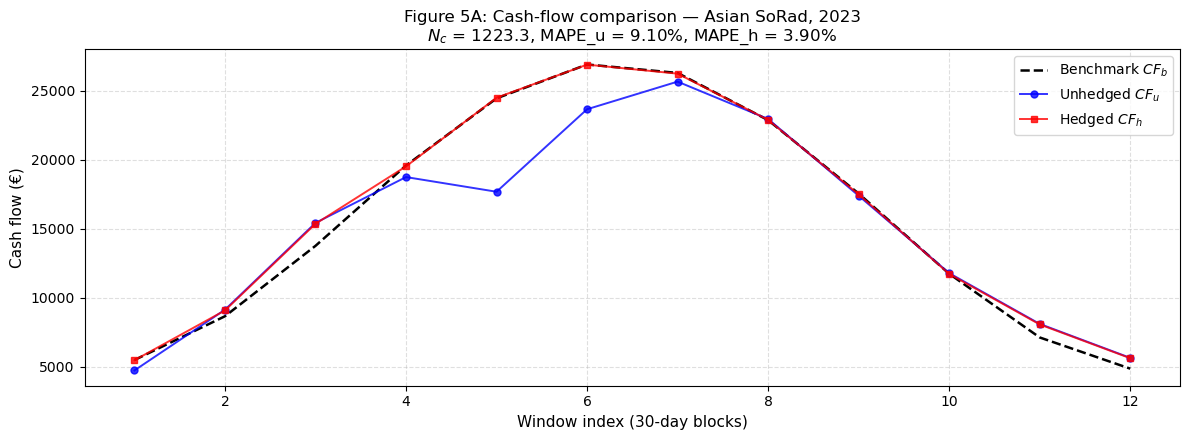

Saved to results/Figure5A_Asian_CashFlows.png


In [25]:
last_rec  = records[-1]
last_year = last_rec['eval_year']
n_win     = len(last_rec['_CF_u'])
win_idx   = np.arange(1, n_win + 1)

fig, ax = plt.subplots(figsize=(12, 4.5))

ax.plot(win_idx, last_rec['_CF_b'], 'k--', lw=1.8,           label='Benchmark $CF_b$')
ax.plot(win_idx, last_rec['_CF_u'], 'b-o', lw=1.4, ms=5, alpha=0.8, label='Unhedged $CF_u$')
ax.plot(win_idx, last_rec['_CF_h'], 'r-s', lw=1.4, ms=5, alpha=0.8, label='Hedged $CF_h$')

ax.set_xlabel(f'Window index ({T_WINDOW}-day blocks)', fontsize=11)
ax.set_ylabel('Cash flow (€)', fontsize=11)
ax.set_title(
    f'Figure 5A: Cash-flow comparison — Asian SoRad, {last_year}\n'
    f'$N_c$ = {last_rec["N_c_opt"]:.1f}, '
    f'MAPE_u = {last_rec["unhedged_MAPE"]:.2f}%, '
    f'MAPE_h = {last_rec["hedged_MAPE"]:.2f}%',
    fontsize=12
)
ax.legend(fontsize=10)
ax.grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('../results/Figure5A_Asian_CashFlows.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to results/Figure5A_Asian_CashFlows.png')

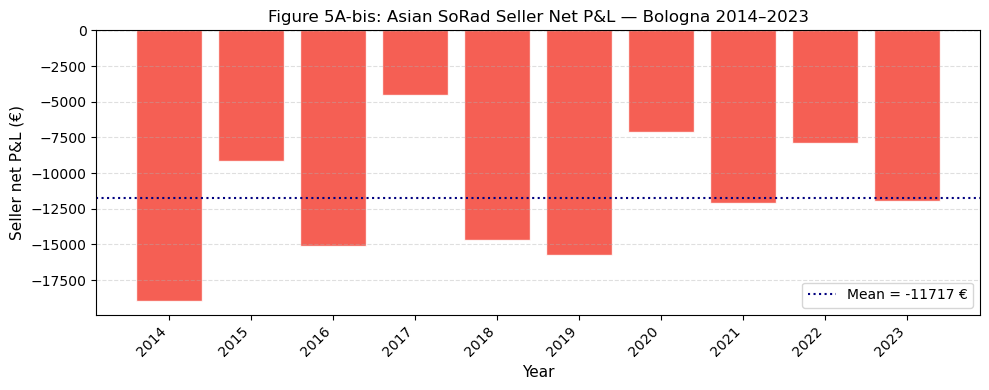

Saved to results/Figure5A_bis_Asian_SellerPnL.png


In [26]:
seller_pnl = table2A['seller_net_eur'].values
colors     = ['#4CAF50' if v >= 0 else '#F44336' for v in seller_pnl]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(years, seller_pnl, color=colors, alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axhline(
    table2A['seller_net_eur'].mean(), color='navy', linewidth=1.5,
    linestyle=':', label=f'Mean = {table2A["seller_net_eur"].mean():.0f} €'
)

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Seller net P&L (€)', fontsize=11)
ax.set_title('Figure 5A-bis: Asian SoRad Seller Net P&L — Bologna 2014–2023', fontsize=12)
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45, ha='right')
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('../results/Figure5A_bis_Asian_SellerPnL.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to results/Figure5A_bis_Asian_SellerPnL.png')